Monte Carlo Estimation of π
True value of π: 3.1415926536

Samples:     100 | π estimate: 3.2400000000 | Error: 0.0984073464
Samples:   1,000 | π estimate: 3.1040000000 | Error: 0.0375926536
Samples:  10,000 | π estimate: 3.1484000000 | Error: 0.0068073464
Samples: 100,000 | π estimate: 3.1368400000 | Error: 0.0047526536
Samples: 1,000,000 | π estimate: 3.1409280000 | Error: 0.0006646536

Visualization with 10,000 samples:


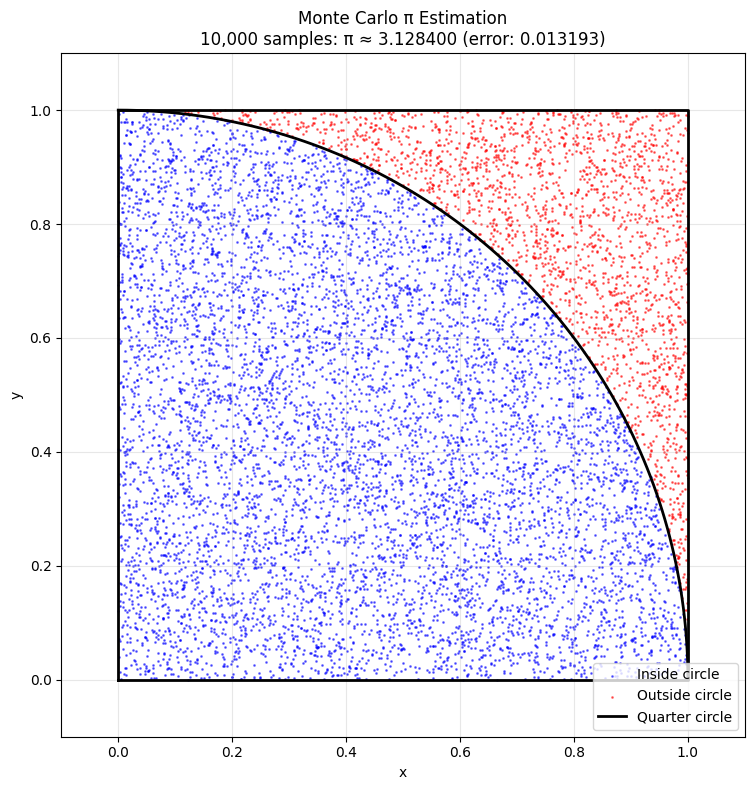


Convergence demonstration:


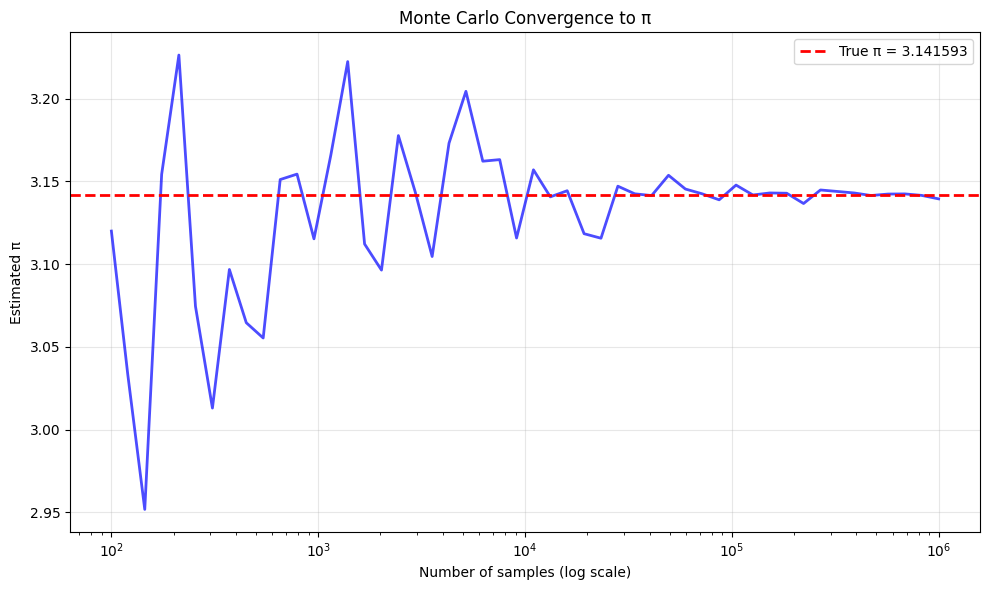

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_pi_monte_carlo(n_samples):
    """
    Estimate π using Monte Carlo simulation.
    
    Method: Randomly throw darts at a square. Count how many land inside
    a quarter circle inscribed in the square.
    
    The ratio of points inside the circle to total points ≈ π/4
    """
    # Generate random points in a 1x1 square
    x = np.random.uniform(0, 1, n_samples)
    y = np.random.uniform(0, 1, n_samples)
    
    # Calculate distance from origin (0,0)
    distances = np.sqrt(x**2 + y**2)
    
    # Count points inside the quarter circle (radius = 1)
    inside_circle = np.sum(distances <= 1)
    
    # Estimate π
    # Area of quarter circle = π/4
    # Area of square = 1
    # Ratio = (π/4) / 1 = π/4
    # So π ≈ 4 * (points inside / total points)
    pi_estimate = 4 * inside_circle / n_samples
    
    return pi_estimate, x, y, distances

# Run simulation with different sample sizes
sample_sizes = [100, 1000, 10000, 100000, 1000000]

print("Monte Carlo Estimation of π")
print("=" * 50)
print(f"True value of π: {np.pi:.10f}\n")

for n in sample_sizes:
    pi_est, _, _, _ = estimate_pi_monte_carlo(n)
    error = abs(pi_est - np.pi)
    print(f"Samples: {n:>7,} | π estimate: {pi_est:.10f} | Error: {error:.10f}")

# Visualize with 10,000 points
print("\n" + "=" * 50)
print("Visualization with 10,000 samples:")

n_viz = 10000
pi_est, x, y, distances = estimate_pi_monte_carlo(n_viz)

# Create plot
plt.figure(figsize=(8, 8))

# Points inside circle (blue), outside (red)
inside = distances <= 1
plt.scatter(x[inside], y[inside], c='blue', s=1, alpha=0.5, label='Inside circle')
plt.scatter(x[~inside], y[~inside], c='red', s=1, alpha=0.5, label='Outside circle')

# Draw the quarter circle
theta = np.linspace(0, np.pi/2, 100)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
plt.plot(circle_x, circle_y, 'black', linewidth=2, label='Quarter circle')

# Draw the square
plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], 'black', linewidth=2)

plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.gca().set_aspect('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Monte Carlo π Estimation\n{n_viz:,} samples: π ≈ {pi_est:.6f} (error: {abs(pi_est - np.pi):.6f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show convergence over iterations
print("\nConvergence demonstration:")
iterations = np.logspace(2, 6, 50, dtype=int)  # 100 to 1,000,000 samples
estimates = []

for n in iterations:
    pi_est, _, _, _ = estimate_pi_monte_carlo(n)
    estimates.append(pi_est)

plt.figure(figsize=(10, 6))
plt.semilogx(iterations, estimates, 'b-', alpha=0.7, linewidth=2)
plt.axhline(y=np.pi, color='r', linestyle='--', linewidth=2, label=f'True π = {np.pi:.6f}')
plt.xlabel('Number of samples (log scale)')
plt.ylabel('Estimated π')
plt.title('Monte Carlo Convergence to π')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()